# Week 5 — Streaming Learner & AutoML (Track A)
**Supervised auto-tuned kNN retriever using Optuna**

Pipeline: Load real PDFs → Baseline → Optuna 100-trial search → Best config eval → River online learner → Report

In [ ]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from data_utils import load_data
from retriever import HybridRetriever
from evaluation import ndcg_at_k, recall_at_k, measure_p95_latency, plot_prequential, evaluate_semantic
from automl import run_study, export_run_card
from online_learner import AdaptiveWeightLearner, simulate_feedback_stream

print('Imports OK')

## 1. Load data (real PDFs from data/)

In [11]:
# Automatically ingests PDFs if corpus.json does not exist yet.
# Never calls save_synthetic — always uses real data.
corpus, queries, qrels = load_data(data_dir='../data')
print(f'Sample doc  : {corpus[0][:120]}')
print(f'Sample query: {queries[0][:100]}')

Loaded real data: 100 docs, 100 queries
Sample doc  : Autonomous LLM agents do not read—theyretrieve. ObjectGraph: From Document Injection to Knowledge Traversal A Native Fil
Sample query: autonomous llm agents do not read—theyretrieve


## 2. Baseline evaluation (default HybridRetriever)

In [12]:
baseline = HybridRetriever()   # k=10, cosine, svd_dim=128, l2, alpha=0.5
baseline.fit(corpus)

baseline_ndcg   = float(np.mean([ndcg_at_k(baseline.retrieve(q), r)   for q, r in zip(queries, qrels)]))
baseline_recall = float(np.mean([recall_at_k(baseline.retrieve(q), r) for q, r in zip(queries, qrels)]))
baseline_p95    = measure_p95_latency(baseline, queries)

print(f'Baseline NDCG@5:   {baseline_ndcg:.4f}')
print(f'Baseline Recall@5: {baseline_recall:.4f}')
print(f'Baseline p95 (ms): {baseline_p95:.2f}')

Baseline NDCG@5:   0.1410
Baseline Recall@5: 0.1750
Baseline p95 (ms): 1.05


## 3. Optuna AutoML search (100 trials per sampler)
Search space: k∈[1,**5**], metric∈{cosine,euclidean,dot_product}, svd_dim∈[32,512], norm∈{l2,none,minmax}, alpha∈[0,1]  
Samplers compared: **TPESampler(seed=42)** (Bayesian) vs **RandomSampler(seed=42)** (unguided baseline)  
Pruner: **MedianPruner(n_startup=10, n_warmup=3)** | Constraint: p95 ≤ 100 ms

In [ ]:
best_params_raw, study_tpe, study_rand = run_study(corpus, queries, qrels, n_trials=100)

print(f'TPE    — {len(study_tpe.trials)} trials,  best NDCG@5: {study_tpe.best_value:.4f}')
print(f'Random — {len(study_rand.trials)} trials, best NDCG@5: {study_rand.best_value:.4f}')
print(f'Best params: {best_params_raw}')

## 4. Evaluate best config & export run card

In [ ]:
best_params = {
    'k':             best_params_raw['k'],
    'metric':        best_params_raw['metric'],
    'svd_dim':       best_params_raw['svd_dim'],
    'normalization': best_params_raw['norm'],
    'hybrid_weight': best_params_raw['alpha'],
}

best = HybridRetriever(**best_params)
best.fit(corpus)

best_ndcg    = float(np.mean([ndcg_at_k(best.retrieve(q), r)   for q, r in zip(queries, qrels)]))
best_recall  = float(np.mean([recall_at_k(best.retrieve(q), r) for q, r in zip(queries, qrels)]))
best_p95     = measure_p95_latency(best, queries)
best_sem_sim = evaluate_semantic(queries, best, corpus)   # semantic layer

print(f'Best NDCG@5:         {best_ndcg:.4f}  (baseline {baseline_ndcg:.4f}, d={best_ndcg-baseline_ndcg:+.4f})')
print(f'Best Recall@5:       {best_recall:.4f}  (baseline {baseline_recall:.4f})')
print(f'Semantic sim @5:     {best_sem_sim:.4f}  (TF-IDF cosine query↔retrieved docs)')
print(f'Best p95 (ms):       {best_p95:.2f}')

In [ ]:
export_run_card(best_params_raw, best_ndcg, best_recall, out_path='../configs/run_card.yaml')

## 5. River online learner — adaptive weight + ADWIN drift detection

In [ ]:
learner = AdaptiveWeightLearner(initial_alpha=best_params['hybrid_weight'])
stream  = simulate_feedback_stream(n_events=1000)

# Stream now yields (bm25_top1, dense_top1, score_gap, label) — all derived
# from what the retriever would actually output per query.
for idx, (bm25_top1, dense_top1, score_gap, label) in enumerate(stream):
    learner.update(bm25_top1, dense_top1, score_gap, label, idx)

learner.export('../outputs/prequential_log.json')
print(f'Final accuracy: {learner.metric.get():.4f}')
print()
print(learner.drift_summary())

## 6. Prequential chart

Saved prequential chart -> ../outputs/prequential_chart.pdf


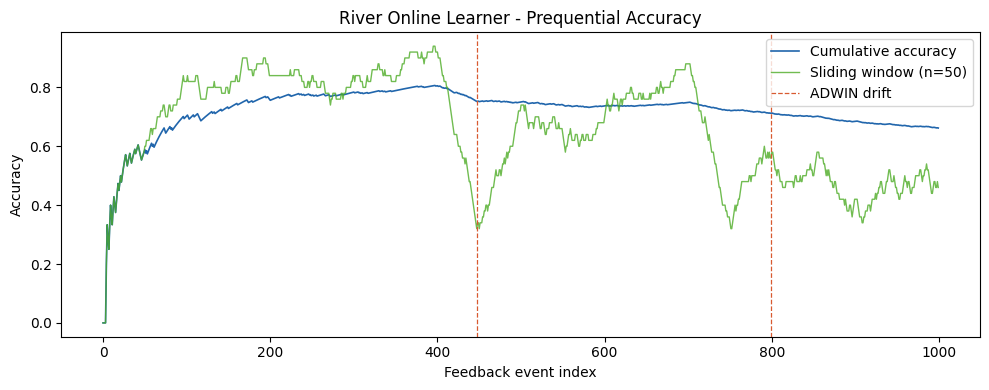

In [17]:
plot_prequential('../outputs/prequential_log.json', '../outputs/prequential_chart.pdf')

import json, matplotlib.pyplot as plt
with open('../outputs/prequential_log.json', encoding='utf-8') as f:
    log = json.load(f)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(log['values'],          linewidth=1.2, label='Cumulative accuracy', color='#2166AC')
ax.plot(log['windowed_values'], linewidth=1.0, alpha=0.8,
        label=f"Sliding window (n={log['windowed_size']})", color='#4DAC26')
for i, dp in enumerate(log['drift_points']):
    ax.axvline(dp, color='#D85A30', linestyle='--', linewidth=0.9,
               label='ADWIN drift' if i == 0 else '')
ax.set_xlabel('Feedback event index'); ax.set_ylabel('Accuracy')
ax.set_title('River Online Learner - Prequential Accuracy')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Summary

In [ ]:
from IPython.display import Markdown

table = f"""
## Summary

| Metric | Baseline | AutoML Best | Delta |
|--------|----------|-------------|-------|
| NDCG@5 | {baseline_ndcg:.4f} | {best_ndcg:.4f} | {best_ndcg-baseline_ndcg:+.4f} |
| Recall@5 | {baseline_recall:.4f} | {best_recall:.4f} | {best_recall-baseline_recall:+.4f} |
| Semantic Sim@5 | — | {best_sem_sim:.4f} | — |
| p95 latency (ms) | {baseline_p95:.2f} | {best_p95:.2f} | {best_p95-baseline_p95:+.2f} |

**Sampler comparison:** TPE best = {study_tpe.best_value:.4f} | Random best = {study_rand.best_value:.4f}
"""
display(Markdown(table))